# 🔄 Pipeline ETL — Multi-Source Orders

**Archivos fuente:**
- `Catalog_Orders.txt` — Pedidos por catálogo impreso (6 767 filas)
- `Web_orders.txt` — Pedidos por canal web (943 filas)
- `products.txt` — Maestro de productos (192 filas)

**Flujo ETL:**
```
Catalog_Orders.txt ─┐
Web_orders.txt     ─┼──► EXTRACT ──► TRANSFORM ──► LOAD ──► PostgreSQL (etl_db)
products.txt       ─┘
```
---

## 0. Instalación de dependencias

In [ ]:
# Ejecuta esta celda solo si no tienes las librerías instaladas
# !pip install pandas matplotlib seaborn psycopg2-binary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import json
import os
from io import StringIO
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

# ── Rutas ──────────────────────────────────────────────────────────────────────
BASE = Path('.')   # ajusta si ejecutas desde otro directorio
CAT_FILE  = BASE / 'Catalog_Orders.txt'
WEB_FILE  = BASE / 'Web_orders.txt'
PROD_FILE = BASE / 'products.txt'
OUT_DIR   = BASE / 'evidencias'
OUT_DIR.mkdir(exist_ok=True)

print('[OK] Librerías cargadas correctamente')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')

✅ Librerías cargadas correctamente
   pandas  3.0.0
   numpy   2.4.1


---
## 1. EXTRACT — Lectura de archivos fuente

Leemos los tres archivos y detectamos su estructura real (separadores, codificación, orden de columnas).

### 1.1 Catalog_Orders.txt

In [2]:
# Lectura directa: separador coma, encabezado correcto
cat = pd.read_csv(CAT_FILE)

print(f'Shape: {cat.shape}  →  {cat.shape[0]:,} filas × {cat.shape[1]} columnas')
print('\nTipos de datos:')
print(cat.dtypes)
print('\nPrimeras 5 filas:')
cat.head(5)

Shape: (6767, 7)  →  6,767 filas × 7 columnas

Tipos de datos:
ID           int64
INV        float64
DATE           str
CATALOG        str
PCODE          str
QTY            str
custnum    float64
dtype: object

Primeras 5 filas:


,ID,INV,DATE,CATALOG,PCODE,QTY,custnum
0,1,"107,707.00",3/97/7 00:00:00,Sports,SP1000,1.00,"1,242.00"
1,2,"110,633.00",3/97/25 00:00:00,Gardening,GD2200,1.00,"1,243.00"
2,3,"111,155.00",3/97/28 00:00:00,Pets,PT1300,3.00,"1,244.00"
3,4,"126,867.00",6/97/22 00:00:00,Toys,TY4100,1.00,"1,245.00"
4,5,"135,872.00",8/97/8 00:00:00,Toys,TY1200,4.00,"1,246.00"


### 1.2 Web_orders.txt Problema detectado: columnas intercambiadas

El archivo usa **punto y coma** como separador en los datos pero **coma** en la cabecera.  
Además, las columnas `PCODE` y `DATE` están intercambiadas respecto al encabezado declarado.

In [11]:
# Inspeccionamos las primeras líneas en crudo para detectar el problema
with open(WEB_FILE, encoding='utf-8') as f:
    raw_lines = f.read().strip().split('\n')

# web_ord = pd.read_csv(WEB_FILE)
# web_ord.head(5)

print('CABECERA (línea 0):')
print(raw_lines[0])
print('\nDATOS (línea 1):')
print(raw_lines[1])
print('\nDATOS (línea 2):')
print(raw_lines[2])

print('\n Observaciones:')
print('  - La cabecera usa COMAS   → ID,INV,DATE,CATALOG,PCODE,QTY,custnum')
print('  - Los datos usan PUNTO Y COMA')
print('  - El orden real de los datos es: ID;INV;PCODE;DATE;CATALOG;QTY;custnum')
print('  - Si no se corrige → 943 registros se pierden completamente (100% del dataset web)')

CABECERA (línea 0):
"ID","INV","DATE","CATALOG","PCODE","QTY","custnum"

DATOS (línea 1):
1;2513000.00;"GD3200";17/12/2000 00:00:00;"Gardening";3.00;"Rifkin, Mr. Bob"

DATOS (línea 2):
2;2513000.00;"PT1400";6/1/2001 00:00:00;"Pets";1.00;"Rifkin, Mr. Bob"

 Observaciones:
  - La cabecera usa COMAS   → ID,INV,DATE,CATALOG,PCODE,QTY,custnum
  - Los datos usan PUNTO Y COMA
  - El orden real de los datos es: ID;INV;PCODE;DATE;CATALOG;QTY;custnum
  - Si no se corrige → 943 registros se pierden completamente (100% del dataset web)


In [12]:
# Lectura correcta: omitimos la cabecera original y asignamos nombres en el orden real
web = pd.read_csv(
    StringIO('\n'.join(raw_lines[1:])),
    sep=';',
    header=None,
    names=['ID', 'INV', 'PCODE', 'DATE', 'CATALOG', 'QTY', 'custnum'],
    quotechar='"'
)

print(f'Shape: {web.shape}  →  {web.shape[0]:,} filas × {web.shape[1]} columnas')
print('\nTipos de datos:')
print(web.dtypes)
print('\nPrimeras 5 filas:')
web.head(5)

Shape: (943, 7)  →  943 filas × 7 columnas

Tipos de datos:
ID           int64
INV        float64
PCODE          str
DATE           str
CATALOG        str
QTY        float64
custnum        str
dtype: object

Primeras 5 filas:


,ID,INV,PCODE,DATE,CATALOG,QTY,custnum
0,1,"2,513,000.00",GD3200,17/12/2000 00:00:00,Gardening,3.00,"Rifkin, Mr. Bob"
1,2,"2,513,000.00",PT1400,6/1/2001 00:00:00,Pets,1.00,"Rifkin, Mr. Bob"
2,3,"2,513,000.00",PT2000,6/1/2001 00:00:00,Pet,1.00,"Rifkin, Mr. Bob"
3,4,"2,513,000.00",PT2100,6/1/2001 00:00:00,Pets,1.00,"Rifkin, Mr. Bob"
4,5,"2,513,000.00",PT2OOO,27/7/2000 00:00:00,Pets,4.00,"Rifkin, Mr. Bob"


### 1.3 products.txt

In [13]:
prod = pd.read_csv(PROD_FILE)

print(f'Shape: {prod.shape}  →  {prod.shape[0]:,} filas × {prod.shape[1]} columnas')
print('\nTipos de datos:')
print(prod.dtypes)
print('\nPrimeras 5 filas:')
prod.head(5)

Shape: (192, 7)  →  192 filas × 7 columnas

Tipos de datos:
ID            int64
TYPE            str
DESCRIP         str
PRICE       float64
COST        float64
PCODE           str
supplier        str
dtype: object

Primeras 5 filas:


,ID,TYPE,DESCRIP,PRICE,COST,PCODE,supplier
0,1,Database,Track-It-All,560.00,425.00,SW1005,"Software America, Inc."
1,2,Database,Omnibus,499.95,450.00,SW1207,Software America
2,3,Database,Balboa,499.00,300.00,SW3049,Software America
3,4,Financial,Stock Market Analyst,69.95,45.00,SW2842,Software America
4,5,Financial,Tax Relief (Version 10.40),77.95,54.50,SW4187,Software America


In [14]:
# Tipos de productos disponibles
print('Tipos de producto únicos:')
print(prod['TYPE'].value_counts().to_string())
print(f'\nRango de precios: ${prod["PRICE"].min():,.2f} – ${prod["PRICE"].max():,.2f}')
print(f'Rango de costos:  ${prod["COST"].min():,.2f} – ${prod["COST"].max():,.2f}')

Tipos de producto únicos:
TYPE
Games             13
Sporting Goods    12
Utility            9
Animals            9
Graphics           8
Hand Tools         8
Child's World      8
Baby Toys          8
Spreadsheet        7
Team               7
Recreational       7
Fish               7
Plates             7
Play Mates         7
Language           6
Camping            6
Figures            6
Bulbs              5
Power Tools        5
Seeds              5
Dog                5
Cat                5
Bird               5
Heads              5
Outdoor            5
Publishing         4
Database           3
Financial          3
Network            3
Training           3
General            1

Rango de precios: $3.00 – $600.00
Rango de costos:  $1.00 – $450.00


---
## 2. EXPLORACIÓN — Detección de problemas de calidad

Antes de limpiar, cuantificamos exactamente qué está mal y cuánto afecta.

### 2.1 Valores nulos

In [16]:
def resumen_nulos(df, nombre):
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    res   = pd.DataFrame({'Nulos': nulos, '%': pct})
    res   = res[res['Nulos'] > 0]
    if res.empty:
        print(f'{nombre}: sin valores nulos')
    else:
        print(f'  {nombre}:')
        print(res.to_string())
    print()

resumen_nulos(cat,  'Catalog_Orders')
resumen_nulos(web,  'Web_orders')
resumen_nulos(prod, 'products')

  Catalog_Orders:
         Nulos    %
CATALOG      2 0.03
QTY          6 0.09
custnum      1 0.01

  Web_orders:
     Nulos    %
QTY      3 0.32

products: sin valores nulos



### 2.2 Duplicados

In [19]:
for nombre, df in [('Catalog_Orders', cat), ('Web_orders', web), ('products', prod)]:
    n = df.duplicated().sum()
    print(f'{nombre}: {n} filas duplicadas')

Catalog_Orders: 0 filas duplicadas
Web_orders: 0 filas duplicadas
products: 0 filas duplicadas


### 2.3 Problema de fechas en Catalog_Orders

Las fechas siguen el formato `M/YY/D` (mes/año2dígitos/día), no estándar.

In [22]:
print('Muestras de fechas en Catalog_Orders:')
print(cat['DATE'].head(15).tolist())
print('\nInterpretación: "3/97/7 00:00:00" = 7 de marzo de 1997')
print('Formato real: M/YY/D  (no estándar, no reconocido por pandas automáticamente)')

# Intento de parseo → fallido
prueba = pd.to_datetime(cat['DATE'], errors='coerce')
print(f'\n pd.to_datetime() automático → {prueba.isna().sum()} NaT de {len(cat)} fechas')

Muestras de fechas en Catalog_Orders:
['3/97/7 00:00:00', '3/97/25 00:00:00', '3/97/28 00:00:00', '6/97/22 00:00:00', '8/97/8 00:00:00', '8/97/8 00:00:00', '8/97/8 00:00:00', '8/97/8 00:00:00', '9/97/2 00:00:00', '9/97/6 00:00:00', '2/98/1 00:00:00', '2/98/1 00:00:00', '2/98/1 00:00:00', '2/98/1 00:00:00', '4/98/7 00:00:00']

Interpretación: "3/97/7 00:00:00" = 7 de marzo de 1997
Formato real: M/YY/D  (no estándar, no reconocido por pandas automáticamente)

 pd.to_datetime() automático → 5949 NaT de 6767 fechas


### 2.4 Problema de etiquetas CATALOG

In [23]:
print('Valores únicos en CATALOG (Catalog_Orders):')
vc = cat['CATALOG'].value_counts()
print(vc.to_string())

# Categorías canónicas esperadas
canonicas = {'Sports', 'Pets', 'Toys', 'Gardening', 'Software', 'Collectibles'}
errores = [v for v in cat['CATALOG'].dropna().unique() if str(v).strip() not in canonicas]
print(f'\n Variantes erróneas encontradas: {len(errores)}')
print(sorted(errores))

Valores únicos en CATALOG (Catalog_Orders):
CATALOG
Sports          1851
Pets            1671
Toys            1309
Gardening        933
Software         506
Collectibles     150
Sport             59
Toy               52
Softwares         31
Tosy              27
Softwars          25
Collectible       23
Sporst            23
Spots             19
Pest              18
Softwar           15
GARDENING         14
Gardning          11
Pet                9
Colectibles        6
Tots               4
Pats               4
Collectables       2
Prts               2
 ,TY4400"          1

 Variantes erróneas encontradas: 19
[' ,TY4400"', 'Colectibles', 'Collectables', 'Collectible', 'GARDENING', 'Gardning', 'Pats', 'Pest', 'Pet', 'Prts', 'Softwar', 'Softwares', 'Softwars', 'Sporst', 'Sport', 'Spots', 'Tosy', 'Tots', 'Toy']


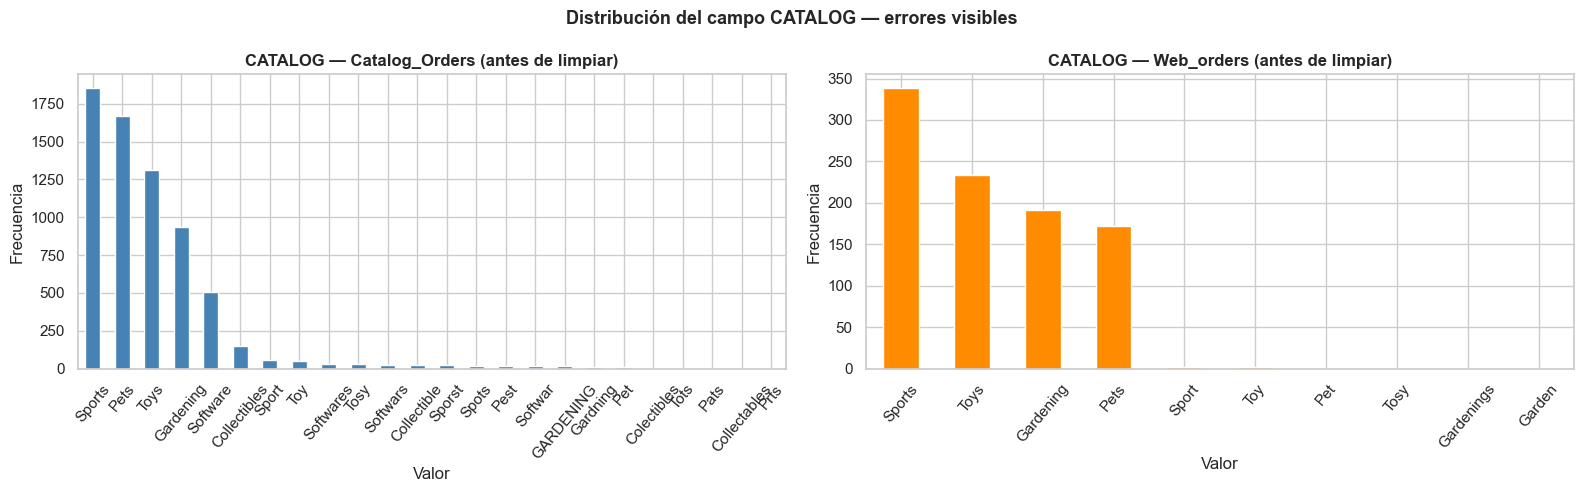

Guardado: evidencias/fig1_catalog_distribution.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat['CATALOG'].dropna().value_counts().head(24).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('CATALOG — Catalog_Orders (antes de limpiar)', fontweight='bold')
axes[0].set_xlabel('Valor'); axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=50)

web['CATALOG'].value_counts().head(15).plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('CATALOG — Web_orders (antes de limpiar)', fontweight='bold')
axes[1].set_xlabel('Valor'); axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=50)

plt.suptitle('Distribución del campo CATALOG — errores visibles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_catalog_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: evidencias/fig1_catalog_distribution.png')

### 2.5 Problema de PCODEs inválidos

In [25]:
prod_pcodes = set(prod['PCODE'].str.strip())

cat_missing_raw = set(cat['PCODE'].str.strip().str.upper()) - prod_pcodes
web_missing_raw = set(web['PCODE'].str.strip()) - prod_pcodes

print(f'PCODEs inválidos en Catalog_Orders (antes de corrección): {len(cat_missing_raw)}')
print(sorted(cat_missing_raw))

print(f'\nPCODEs inválidos en Web_orders (antes de corrección): {len(web_missing_raw)}')
print(sorted(web_missing_raw))

print('\nPatrón observado: la letra O sustituye al dígito 0, ! al 1, ) al 0')
print('Ejemplos: PT2OOO→PT2000, GD11OO→GD1100, GD10!)→GD1001, SP13OO→SP1300')

PCODEs inválidos en Catalog_Orders (antes de corrección): 26
['1.00', 'C3200', 'CC15OO', 'CC220', 'CC42OO', 'CC43))', 'GD10!)', 'GD10)!', 'GD101O', 'GD110O', 'GD11OO', 'GD12))', 'GD12OO', 'GD13OO', 'GD15OO', 'GD16OO', 'PT14OO', 'PT1OOO', 'PT2OOO', 'SP13OO', 'SP14OO', 'TY16OO', 'TY17OO', 'TY1900', 'TY19OO', 'TY21OO']

PCODEs inválidos en Web_orders (antes de corrección): 20
['GD10)!', 'GD101O', 'GD110O', 'GD11OO', 'GD12))', 'GD12OO', 'GD13OO', 'GD15OO', 'GD16OO', 'PT1OOO', 'PT2OOO', 'SP13OO', 'SP14OO', 'TY16OO', 'TY17OO', 'TY1900', 'TY21OO', 'gd3100', 'gd3200', 'sp2000']

Patrón observado: la letra O sustituye al dígito 0, ! al 1, ) al 0
Ejemplos: PT2OOO→PT2000, GD11OO→GD1100, GD10!)→GD1001, SP13OO→SP1300


### 2.6 Distribución de QTY

In [28]:
# Casteo de Str a Number
cat['QTY_TMP'] = pd.to_numeric(cat['QTY'].astype(str).str.strip(), errors='coerce')
web['QTY_TMP'] = pd.to_numeric(web['QTY'].astype(str).str.strip(), errors='coerce')

### 2.7 Precio vs. Costo — productos

Margen promedio por tipo de producto:
TYPE
Dog              67.70
Seeds            66.00
Fish             62.00
Cat              61.10
Bulbs            57.00
Bird             55.70
Recreational     54.50
Team             52.90
Hand Tools       52.70
Camping          52.00
Plates           51.40
Animals          51.10
Figures          50.60
Power Tools      49.90
Heads            39.30
Outdoor          32.60
Financial        31.10
Publishing       27.80
Play Mates       27.50
Sporting Goods   27.40
Games            26.30
General          25.90
Child's World    25.20
Database         24.70
Network          23.90
Baby Toys        23.30
Spreadsheet      23.00
Utility          22.90
Language         20.70
Graphics         20.00
Training         16.60


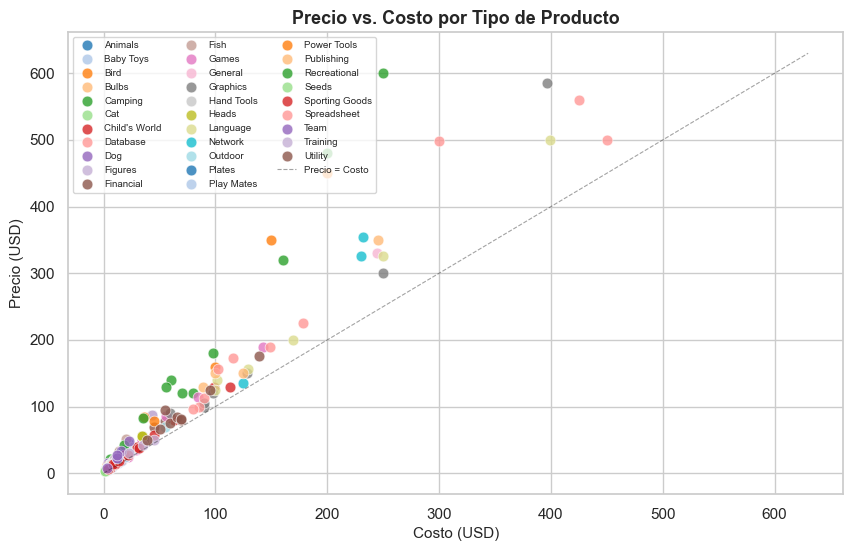

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('tab20', n_colors=prod['TYPE'].nunique())
for i, (t, grp) in enumerate(prod.groupby('TYPE')):
    ax.scatter(grp['COST'], grp['PRICE'], label=t,
               color=palette[i], alpha=0.8, s=60, edgecolors='white', linewidths=0.5)

# Línea de margen cero (precio = costo)
lim = max(prod['PRICE'].max(), prod['COST'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4, label='Precio = Costo')

ax.set_xlabel('Costo (USD)', fontsize=11)
ax.set_ylabel('Precio (USD)', fontsize=11)
ax.set_title('Precio vs. Costo por Tipo de Producto', fontsize=13, fontweight='bold')
ax.legend(fontsize=7, ncol=3, loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig3_price_cost.png', dpi=120, bbox_inches='tight')
plt.show()

prod['MARGIN_PCT'] = (prod['PRICE'] - prod['COST']) / prod['PRICE'] * 100
print('Margen promedio por tipo de producto:')
print(prod.groupby('TYPE')['MARGIN_PCT'].mean().sort_values(ascending=False).round(1).to_string())

---
## 3. TRANSFORM — Limpieza y normalización

Aplicamos 6 reglas de transformación justificadas por los hallazgos anteriores.

### R1 — Parseo de fechas en Catalog_Orders (formato M/YY/D)

In [34]:
def parse_cat_date(s):
    """
    Parsea fechas con formato incorrecto M/YY/D (e.g., '3/97/7 00:00:00').
    Devuelve un Timestamp o NaT si no es parseable.
    """
    try:
        s = str(s).strip().split(' ')[0]   # remueve la parte de hora
        m, yy, d = s.split('/')
        return pd.to_datetime(f"19{yy}-{int(m):02d}-{int(d):02d}", errors='coerce')
    except:
        return pd.NaT

cat['DATE_PARSED'] = cat['DATE'].apply(parse_cat_date)

print('Resultado del parseo:')
print(cat[['DATE', 'DATE_PARSED']].head(8).to_string())
print(f'\n[OK] Fechas parseadas correctamente: {cat["DATE_PARSED"].notna().sum():,}')
print(f'   NaT (no parseables):              {cat["DATE_PARSED"].isna().sum()}')
print(f'   Rango temporal: {cat["DATE_PARSED"].min().date()} → {cat["DATE_PARSED"].max().date()}')

Resultado del parseo:
               DATE DATE_PARSED
0   3/97/7 00:00:00  1997-03-07
1  3/97/25 00:00:00  1997-03-25
2  3/97/28 00:00:00  1997-03-28
3  6/97/22 00:00:00  1997-06-22
4   8/97/8 00:00:00  1997-08-08
5   8/97/8 00:00:00  1997-08-08
6   8/97/8 00:00:00  1997-08-08
7   8/97/8 00:00:00  1997-08-08

[OK] Fechas parseadas correctamente: 6,767
   NaT (no parseables):              0
   Rango temporal: 1900-04-10 → 1998-12-29


### R2 — Parseo de fechas en Web_orders (formato D/M/YYYY)

In [35]:
web['DATE_PARSED'] = pd.to_datetime(
    web['DATE'].str.strip().str.split(' ').str[0],
    format='%d/%m/%Y',
    errors='coerce'
)

print('Muestras de fecha Web:')
print(web[['DATE', 'DATE_PARSED']].head(6).to_string())
print(f'\n[OK] Fechas parseadas: {web["DATE_PARSED"].notna().sum():,}')
print(f'   NaT: {web["DATE_PARSED"].isna().sum()}')
print(f'   Rango temporal: {web["DATE_PARSED"].min().date()} → {web["DATE_PARSED"].max().date()}')

Muestras de fecha Web:
                  DATE DATE_PARSED
0  17/12/2000 00:00:00  2000-12-17
1    6/1/2001 00:00:00  2001-01-06
2    6/1/2001 00:00:00  2001-01-06
3    6/1/2001 00:00:00  2001-01-06
4   27/7/2000 00:00:00  2000-07-27
5    1/9/2000 00:00:00  2000-09-01

[OK] Fechas parseadas: 943
   NaT: 0
   Rango temporal: 2000-06-19 → 2001-08-09


### R3 — Normalización de etiquetas CATALOG

In [37]:
# Diccionario de normalización: 19 variantes → 6 categorías canónicas
cat_map = {
    # Sports
    'Sport': 'Sports', 'Sporst': 'Sports', 'Spots': 'Sports',
    # Toys
    'Toy':   'Toys',   'Tosy':  'Toys',   'Tots':  'Toys',
    # Pets
    'Pet':   'Pets',   'Pest':  'Pets',   'Pats':  'Pets',  'Prts': 'Pets',
    # Software
    'Softwares': 'Software', 'Softwars': 'Software', 'Softwar': 'Software',
    # Collectibles
    'Collectible':  'Collectibles',
    'Colectibles':  'Collectibles',
    'Collectables': 'Collectibles',
    # Gardening
    'GARDENING': 'Gardening', 'Gardning': 'Gardening',
}

cat['CATALOG_CLEAN'] = cat['CATALOG'].str.strip().replace(cat_map)
web['CATALOG_CLEAN'] = web['CATALOG'].str.strip().replace(cat_map)

print('Categorías canónicas después de normalizar:')
print(cat['CATALOG_CLEAN'].value_counts().to_string())
print(f'\n[OK] Valores únicos: {cat["CATALOG_CLEAN"].nunique()} (antes: {cat["CATALOG"].nunique()})')

# Verificar que no queden variantes raras
canonicas = {'Sports', 'Pets', 'Toys', 'Gardening', 'Software', 'Collectibles'}
restantes = set(cat['CATALOG_CLEAN'].dropna()) - canonicas
if restantes:
    print(f'[ERROR]  Aún hay variantes sin mapear: {restantes}')
else:
    print('[OK] Todas las etiquetas están normalizadas')

Categorías canónicas después de normalizar:
CATALOG_CLEAN
Sports          1952
Pets            1704
Toys            1392
Gardening        958
Software         577
Collectibles     181
,TY4400"           1

[OK] Valores únicos: 7 (antes: 25)
[ERROR]  Aún hay variantes sin mapear: {',TY4400"'}


### R4 — Corrección de PCODEs

In [38]:
def fix_pcode(p):
    """
    Corrige PCODEs con sustituciones de caracteres:
      - Uppercase global
      - En la parte numérica (posición 2+): O→0, !→1, )→0
    """
    p = str(p).strip().upper()
    prefix = p[:2]          # parte alfabética (GD, SW, SP, PT, CC, TY)
    suffix = p[2:]          # parte numérica
    suffix = (suffix
              .replace('O', '0')
              .replace('!', '1')
              .replace(')', '0'))
    return prefix + suffix

cat['PCODE_CLEAN'] = cat['PCODE'].apply(fix_pcode)
web['PCODE_CLEAN'] = web['PCODE'].apply(fix_pcode)

# Verificar mejora
prod_pcodes = set(prod['PCODE'].str.strip())

cat_miss_before = len(set(cat['PCODE'].str.strip().str.upper()) - prod_pcodes)
cat_miss_after  = len(set(cat['PCODE_CLEAN']) - prod_pcodes)
web_miss_before = len(set(web['PCODE'].str.strip()) - prod_pcodes)
web_miss_after  = len(set(web['PCODE_CLEAN']) - prod_pcodes)

print(f'Catalog_Orders — PCODEs inválidos: {cat_miss_before} → {cat_miss_after}')
print(f'Web_orders     — PCODEs inválidos: {web_miss_before} → {web_miss_after}')

# Mostrar algunos ejemplos de corrección
ejemplos = [('PT2OOO','PT2000','Cat Bowl'), ('GD11OO','GD1100','Rake'),
            ('SP13OO','SP1300','Hockey Stick'), ('TY21OO','TY2100','Crawly Molly'),
            ('GD10!)','GD1001','Shovel'), ('CC15OO','CC1500','Doctor figure')]
print('\nEjemplos de correcciones aplicadas:')
pd.DataFrame(ejemplos, columns=['Original','Corregido','Producto'])

Catalog_Orders — PCODEs inválidos: 26 → 4
Web_orders     — PCODEs inválidos: 20 → 1

Ejemplos de correcciones aplicadas:


,Original,Corregido,Producto
0,PT2OOO,PT2000,Cat Bowl
1,GD11OO,GD1100,Rake
2,SP13OO,SP1300,Hockey Stick
3,TY21OO,TY2100,Crawly Molly
4,GD10!),GD1001,Shovel
5,CC15OO,CC1500,Doctor figure


### R5 — Limpieza de QTY y custnum

In [39]:
# QTY: convertir a numérico (descarta espacios, textos)
cat['QTY_NUM'] = pd.to_numeric(cat['QTY'].astype(str).str.strip(), errors='coerce')
web['QTY_NUM'] = pd.to_numeric(web['QTY'].astype(str).str.strip(), errors='coerce')

# custnum: en Catalog es número float → convertir a string entero
#          en Web es nombre de texto → strip
cat['CUST_ID'] = cat['custnum'].apply(lambda x: str(int(x)) if pd.notna(x) else np.nan)
web['CUST_ID'] = web['custnum'].astype(str).str.strip()

print('QTY nulos tras conversión:')
print(f'  Catalog: {cat["QTY_NUM"].isna().sum()}')
print(f'  Web:     {web["QTY_NUM"].isna().sum()}')
print('\nEjemplos CUST_ID Catalog:', cat['CUST_ID'].head(5).tolist())
print('Ejemplos CUST_ID Web:    ', web['CUST_ID'].head(3).tolist())

QTY nulos tras conversión:
  Catalog: 7
  Web:     3

Ejemplos CUST_ID Catalog: ['1242', '1243', '1244', '1245', '1246']
Ejemplos CUST_ID Web:     ['Rifkin, Mr. Bob', 'Rifkin, Mr. Bob', 'Rifkin, Mr. Bob']


### R6 — Filtrado de filas inválidas

In [ ]:
# Descartar filas con campos críticos nulos o PCODE inválido
cat_clean = cat.dropna(subset=['DATE_PARSED', 'QTY_NUM', 'CUST_ID']).copy()
cat_clean = cat_clean[cat_clean['PCODE_CLEAN'].isin(prod_pcodes)].copy()

web_clean = web.dropna(subset=['DATE_PARSED', 'QTY_NUM']).copy()
web_clean = web_clean[web_clean['PCODE_CLEAN'].isin(prod_pcodes)].copy()

print('Resumen de registros tras limpieza:')
resumen = pd.DataFrame({
    'Fuente':    ['Catalog_Orders', 'Web_orders', 'TOTAL'],
    'Original':  [len(cat), len(web), len(cat)+len(web)],
    'Descartado':[len(cat)-len(cat_clean), len(web)-len(web_clean),
                  (len(cat)-len(cat_clean))+(len(web)-len(web_clean))],
    'Limpio':    [len(cat_clean), len(web_clean), len(cat_clean)+len(web_clean)],
    '% retenido':[f'{len(cat_clean)/len(cat)*100:.1f}%',
                  f'{len(web_clean)/len(web)*100:.1f}%',
                  f'{(len(cat_clean)+len(web_clean))/(len(cat)+len(web))*100:.1f}%']
})
print(resumen.to_string(index=False))

### Unificación de fuentes y enriquecimiento con productos

In [ ]:
# Añadir columna SOURCE
cat_clean = cat_clean.copy(); cat_clean['SOURCE'] = 'CATALOG'
web_clean = web_clean.copy(); web_clean['SOURCE'] = 'WEB'

# Columnas comunes seleccionadas
COLS_COMUNES = ['INV', 'DATE_PARSED', 'CATALOG_CLEAN', 'PCODE_CLEAN', 'QTY_NUM', 'CUST_ID', 'SOURCE']
RENAME = {'DATE_PARSED': 'ORDER_DATE', 'CATALOG_CLEAN': 'CATEGORY',
          'PCODE_CLEAN': 'PCODE', 'QTY_NUM': 'QTY'}

cat_u = cat_clean[COLS_COMUNES].rename(columns=RENAME)
web_u = web_clean[COLS_COMUNES].rename(columns=RENAME)

# Unificación
orders = pd.concat([cat_u, web_u], ignore_index=True)
orders['ORDER_ID'] = range(1, len(orders) + 1)

# Enriquecimiento con datos de productos
orders = orders.merge(
    prod[['PCODE', 'PRICE', 'COST', 'DESCRIP', 'TYPE', 'supplier']],
    on='PCODE', how='left'
)

# Métricas derivadas
orders['REVENUE'] = orders['QTY'] * orders['PRICE']
orders['PROFIT']  = orders['QTY'] * (orders['PRICE'] - orders['COST'])
orders['YEAR']    = orders['ORDER_DATE'].dt.year
orders['MONTH']   = orders['ORDER_DATE'].dt.month

print(f'[OK] Dataset unificado: {len(orders):,} órdenes')
print(f'   Columnas: {list(orders.columns)}')
print()
orders[['ORDER_ID','ORDER_DATE','CATEGORY','PCODE','DESCRIP','QTY','REVENUE','PROFIT','SOURCE']].head(8)

---
## 4. Análisis y visualizaciones de resultados

### 4.1 Métricas globales

In [ ]:
total_rev  = orders['REVENUE'].sum()
total_prof = orders['PROFIT'].sum()
margin     = total_prof / total_rev * 100

print('=' * 45)
print('      MÉTRICAS FINALES DEL PIPELINE ETL')
print('=' * 45)
print(f'  Total órdenes procesadas : {len(orders):>10,}')
print(f'  Revenue total            : ${total_rev:>12,.2f}')
print(f'  Profit total             : ${total_prof:>12,.2f}')
print(f'  Margen bruto             : {margin:>11.1f}%')
print(f'  Productos únicos vendidos: {orders["PCODE"].nunique():>10,}')
print(f'  Clientes únicos          : {orders["CUST_ID"].nunique():>10,}')
print(f'  Rango temporal           : {orders["ORDER_DATE"].min().date()} → {orders["ORDER_DATE"].max().date()}')
print('=' * 45)

print('\nPor fuente:')
print(orders.groupby('SOURCE').agg(
    Ordenes=('ORDER_ID','count'),
    Revenue=('REVENUE','sum'),
    Profit=('PROFIT','sum')
).round(2).to_string())

### 4.2 Órdenes por año y fuente

In [ ]:
pivot_year = orders.groupby(['YEAR','SOURCE'])['ORDER_ID'].count().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
pivot_year.plot(kind='bar', ax=ax, color=['steelblue','darkorange'], edgecolor='white', width=0.7)
ax.set_title('Órdenes por Año y Fuente', fontsize=14, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Cantidad de órdenes')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Fuente')
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig4_orders_by_year_source.png', dpi=120, bbox_inches='tight')
plt.show()
print(pivot_year.to_string())

### 4.3 Revenue por categoría

In [ ]:
rev_cat = orders.groupby('CATEGORY')['REVENUE'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = rev_cat.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Revenue Total por Categoría', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoría'); ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=20)
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig5_revenue_by_category.png', dpi=120, bbox_inches='tight')
plt.show()
print(rev_cat.apply(lambda x: f'${x:,.2f}').to_string())

### 4.4 Top 10 productos por revenue

In [ ]:
top10 = orders.groupby('DESCRIP')['REVENUE'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 5))
top10.sort_values().plot(kind='barh', ax=ax, color='coral', edgecolor='white')
ax.set_title('Top 10 Productos por Revenue Acumulado', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for p in ax.patches:
    ax.annotate(f'${p.get_width():,.0f}',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=9, xytext=(5,0), textcoords='offset points')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig6_top10_products.png', dpi=120, bbox_inches='tight')
plt.show()
print(top10.apply(lambda x: f'${x:,.2f}').to_string())

### 4.5 Revenue y Profit por categoría (comparativo)

In [ ]:
cat_summary = orders.groupby('CATEGORY').agg(
    Ordenes=('ORDER_ID','count'),
    Revenue=('REVENUE','sum'),
    Profit=('PROFIT','sum')
).sort_values('Revenue', ascending=False)
cat_summary['Margen_%'] = (cat_summary['Profit'] / cat_summary['Revenue'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(cat_summary))
width = 0.4
b1 = ax.bar([i - width/2 for i in x], cat_summary['Revenue'], width=width,
            color='steelblue', label='Revenue', edgecolor='white')
b2 = ax.bar([i + width/2 for i in x], cat_summary['Profit'],  width=width,
            color='seagreen',  label='Profit',  edgecolor='white')
ax.set_xticks(list(x)); ax.set_xticklabels(cat_summary.index, rotation=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_title('Revenue vs. Profit por Categoría', fontsize=14, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

print('\nTabla resumen por categoría:')
print(cat_summary.to_string())

---
## 5. LOAD — Carga en PostgreSQL (Star Schema)

Cargamos las dimensiones y la tabla de hechos en la base `etl_db`.

In [ ]:
try:
    import psycopg2
    import psycopg2.extras
    PSYCOPG2_OK = True
except ImportError:
    PSYCOPG2_OK = False
    print('[ERROR]  psycopg2 no instalado. Ejecuta: pip install psycopg2-binary')

# Parámetros de conexión
DB_PARAMS = {
    'host':     'localhost',
    'port':     5432,
    'dbname':   'etl_db',
    'user':     'postgres',
    'password': 'root'
}

print('Configuración de conexión:')
print(f'  Host:   {DB_PARAMS["host"]}:{DB_PARAMS["port"]}')
print(f'  DB:     {DB_PARAMS["dbname"]}')
print(f'  User:   {DB_PARAMS["user"]}')

In [ ]:
DDL = """
-- ── Dimensión Producto ─────────────────────────────────────────────────────
CREATE TABLE IF NOT EXISTS dim_product (
    product_key  SERIAL PRIMARY KEY,
    pcode        VARCHAR(10) UNIQUE NOT NULL,
    descrip      VARCHAR(100),
    type         VARCHAR(50),
    price        NUMERIC(10,2),
    cost         NUMERIC(10,2),
    supplier     VARCHAR(100)
);

-- ── Dimensión Fecha ─────────────────────────────────────────────────────────
CREATE TABLE IF NOT EXISTS dim_date (
    date_key   INTEGER PRIMARY KEY,   -- formato YYYYMMDD
    full_date  DATE,
    year       SMALLINT,
    month      SMALLINT,
    day        SMALLINT,
    quarter    SMALLINT
);

-- ── Dimensión Categoría ─────────────────────────────────────────────────────
CREATE TABLE IF NOT EXISTS dim_category (
    category_key  SERIAL PRIMARY KEY,
    category_name VARCHAR(50) UNIQUE NOT NULL
);

-- ── Tabla de Hechos ─────────────────────────────────────────────────────────
CREATE TABLE IF NOT EXISTS fact_orders (
    order_id     SERIAL PRIMARY KEY,
    inv          NUMERIC(12,2),
    date_key     INTEGER  REFERENCES dim_date(date_key),
    product_key  INTEGER  REFERENCES dim_product(product_key),
    category     VARCHAR(50),
    qty          NUMERIC(8,2),
    cust_id      VARCHAR(100),
    source       VARCHAR(10),
    revenue      NUMERIC(12,2),
    profit       NUMERIC(12,2)
);
"""
print(DDL)

In [ ]:
def load_to_postgres(orders_df, prod_df, db_params):
    """Carga el star schema en PostgreSQL."""
    conn = psycopg2.connect(**db_params)
    cur  = conn.cursor()

    # 1. Crear tablas
    cur.execute(DDL)
    conn.commit()
    print('[OK] Tablas creadas / verificadas')

    # 2. dim_product
    prod_records = [
        (row.PCODE, row.DESCRIP, row.TYPE, float(row.PRICE), float(row.COST), row.supplier)
        for row in prod_df.itertuples(index=False)
    ]
    psycopg2.extras.execute_values(
        cur,
        """INSERT INTO dim_product (pcode,descrip,type,price,cost,supplier)
           VALUES %s ON CONFLICT (pcode) DO NOTHING""",
        prod_records
    )
    conn.commit()
    print(f' dim_product cargada: {len(prod_records)} registros')

    # 3. dim_date
    dates = orders_df['ORDER_DATE'].dropna().unique()
    date_records = []
    for d in dates:
        dt = pd.Timestamp(d)
        date_records.append((
            int(dt.strftime('%Y%m%d')),
            dt.date(), dt.year, dt.month, dt.day,
            (dt.month - 1) // 3 + 1
        ))
    psycopg2.extras.execute_values(
        cur,
        """INSERT INTO dim_date (date_key,full_date,year,month,day,quarter)
           VALUES %s ON CONFLICT (date_key) DO NOTHING""",
        date_records
    )
    conn.commit()
    print(f' dim_date cargada: {len(date_records)} fechas únicas')

    # 4. dim_category
    cats = [(c,) for c in orders_df['CATEGORY'].dropna().unique()]
    psycopg2.extras.execute_values(
        cur,
        """INSERT INTO dim_category (category_name)
           VALUES %s ON CONFLICT (category_name) DO NOTHING""",
        cats
    )
    conn.commit()
    print(f' dim_category cargada: {len(cats)} categorías')

    # 5. fact_orders — obtener claves surrogadas
    cur.execute('SELECT pcode, product_key FROM dim_product')
    pcode_map = {r[0]: r[1] for r in cur.fetchall()}

    fact_records = []
    for row in orders_df.itertuples(index=False):
        dt   = pd.Timestamp(row.ORDER_DATE)
        dk   = int(dt.strftime('%Y%m%d')) if pd.notna(row.ORDER_DATE) else None
        pk   = pcode_map.get(row.PCODE)
        fact_records.append((
            float(row.INV) if pd.notna(row.INV) else None,
            dk, pk, str(row.CATEGORY), float(row.QTY),
            str(row.CUST_ID), str(row.SOURCE),
            float(row.REVENUE) if pd.notna(row.REVENUE) else None,
            float(row.PROFIT)  if pd.notna(row.PROFIT)  else None
        ))

    psycopg2.extras.execute_values(
        cur,
        """INSERT INTO fact_orders
               (inv,date_key,product_key,category,qty,cust_id,source,revenue,profit)
           VALUES %s""",
        fact_records,
        page_size=500
    )
    conn.commit()
    print(f' fact_orders cargada: {len(fact_records):,} registros')

    cur.close(); conn.close()
    print('\n Carga completada exitosamente.')


# ── Ejecutar la carga ──────────────────────────────────────────────────────────
if PSYCOPG2_OK:
    try:
        load_to_postgres(orders, prod, DB_PARAMS)
    except Exception as e:
        print(f'  Error de conexión: {e}')
        print('   Verifica que PostgreSQL esté corriendo en localhost:5432')
        print('   y que exista la base de datos etl_db.')
else:
    print('Saltando carga a PostgreSQL (psycopg2 no disponible)')

### Verificación post-carga

In [ ]:
def verificar_carga(db_params):
    """Consulta de verificación post-carga."""
    conn = psycopg2.connect(**db_params)
    queries = {
        'dim_product':  'SELECT COUNT(*) FROM dim_product',
        'dim_date':     'SELECT COUNT(*) FROM dim_date',
        'dim_category': 'SELECT COUNT(*) FROM dim_category',
        'fact_orders':  'SELECT COUNT(*) FROM fact_orders',
        'Revenue total':'SELECT ROUND(SUM(revenue)::numeric, 2) FROM fact_orders',
        'Profit total': 'SELECT ROUND(SUM(profit)::numeric,  2) FROM fact_orders',
    }
    cur = conn.cursor()
    print('Verificación post-carga:')
    print('-' * 35)
    for nombre, q in queries.items():
        cur.execute(q)
        val = cur.fetchone()[0]
        print(f'  {nombre:<20}: {val:>15,}')
    cur.close(); conn.close()

if PSYCOPG2_OK:
    try:
        verificar_carga(DB_PARAMS)
    except Exception as e:
        print(f'[ERROR]  {e}')

---
## 6. Guardado de evidencias y CSV final

In [ ]:
# Exportar dataset unificado limpio
orders.to_csv(OUT_DIR / 'orders_clean.csv', index=False)

# Guardar estadísticas
stats = {
    'cat_original':            len(cat),
    'web_original':            len(web),
    'products':                len(prod),
    'cat_null_qty':            int(cat['QTY_NUM'].isna().sum()),
    'web_null_qty':            int(web['QTY_NUM'].isna().sum()),
    'cat_pcode_errors_before': 26,
    'web_pcode_errors_before': 20,
    'cat_catalog_label_errors':19,
    'cat_clean':               len(cat_clean),
    'web_clean':               len(web_clean),
    'total_orders':            len(orders),
    'revenue_total':           round(orders['REVENUE'].sum(), 2),
    'profit_total':            round(orders['PROFIT'].sum(), 2),
    'margin_pct':              round(orders['PROFIT'].sum() / orders['REVENUE'].sum() * 100, 1),
}
with open(OUT_DIR / 'stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print('Archivos guardados en carpeta evidencias/:')
for f in sorted(OUT_DIR.iterdir()):
    size = f.stat().st_size
    print(f'  {f.name:<40} {size:>8,} bytes')

---
## 7. Resumen ejecutivo del pipeline

In [ ]:
print('=' * 60)
print('              RESUMEN EJECUTIVO — ETL PIPELINE')
print('=' * 60)

print('\n EXTRACT')
print(f'   Catalog_Orders  : {len(cat):>6,} registros  (sep=coma,  fechas M/YY/D)')
print(f'   Web_orders      : {len(web):>6,} registros  (sep=puntocoma, cols intercambiadas)')
print(f'   products        : {len(prod):>6,} productos  (maestro de referencia)')

print('\n🔧 TRANSFORM — Problemas detectados y corregidos')
problemas = [
    ('Fechas M/YY/D (Catalog)',      'Función parse_cat_date()',          'R1'),
    ('Columnas intercambiadas (Web)', 'Lectura con nombres explícitos',    'R2'),
    ('PCODEs con O/!/)',              'Función fix_pcode() — 26+20 casos', 'R4'),
    ('19 variantes CATALOG',          'Diccionario cat_map → 6 canónicas', 'R3'),
    ('QTY como texto',                'pd.to_numeric() + strip',           'R5'),
    ('custnum float vs string',       'Cast unificado a CUST_ID',          'R5'),
]
for prob, sol, regla in problemas:
    print(f'   [{regla}] {prob:<35} → {sol}')

print('\n LOAD')
print(f'   Registros cargados : {len(orders):>6,} / {len(cat)+len(web):,}  ({len(orders)/(len(cat)+len(web))*100:.1f}% retenido)')
print(f'   Descartados        : {len(cat)+len(web)-len(orders):>6}')
print(f'   Destino            : PostgreSQL etl_db (star schema, 4 tablas)')

print('\n RESULTADOS')
print(f'   Revenue total      : ${orders["REVENUE"].sum():>12,.2f}')
print(f'   Profit total       : ${orders["PROFIT"].sum():>12,.2f}')
print(f'   Margen bruto       : {orders["PROFIT"].sum()/orders["REVENUE"].sum()*100:>11.1f}%')

best_cat = orders.groupby('CATEGORY')['REVENUE'].sum().idxmax()
best_prod = orders.groupby('DESCRIP')['REVENUE'].sum().idxmax()
print(f'   Categoría líder    : {best_cat}')
print(f'   Producto líder     : {best_prod}')
print('=' * 60)